# RAG Orchestrator — Movie & TV Plot QA (with LoRA Agent)

Agents:
1. **Classifier + Rewrite Agent** (GPT-4o-mini) — classifies question type and rewrites as HyDE query
2. **LoRA Generator Agent** (SmolLM2-1.7B fine-tuned on NarrativeQA dataset) — answers *factual* questions with short, direct answers
3. **GPT Generator Agent** (GPT-4o-mini) — answers *emotional* and *vague* questions
4. **Title Filter Agent** (GPT-4o-mini) — resolves which show/movie the question is about
5. **Critic Agent** (GPT-4o-mini) — fact-checks the answer against retrieved chunks

## 1. Imports

In [1]:
import os
import json
import time
from dataclasses import dataclass
from enum import Enum
from typing import Any, Dict, List, Optional, TypedDict
import numpy as np
import pandas as pd
from tqdm import tqdm
from dotenv import load_dotenv

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

from langsmith import Client
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.retrievers import BaseRetriever
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import ChatOpenAI
from langchain_pinecone import PineconeVectorStore

from sentence_transformers import CrossEncoder
from langgraph.graph import END, StateGraph
from IPython.display import Image, display

import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import get_peft_model, LoraConfig


/Users/amily/Desktop/stitching-project-evelynh037/genai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Environment & API Keys

In [2]:
load_dotenv()

OPENAI_API_KEY   = os.getenv("OPENAI_API_KEY")
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")

os.environ["OPENAI_API_KEY"]   = OPENAI_API_KEY
os.environ["PINECONE_API_KEY"] = PINECONE_API_KEY

print("✓ API keys loaded")

✓ API keys loaded


## 3. Load LoRA Fine-tuned Model

The LoRA model was fine-tuned on NarrativeQA — a dataset of short, factual plot questions.
It is used as the **factual generator agent** because it is trained to give short, direct answers
grounded in plot context, which is exactly what factual questions need.

In [6]:
BASE_MODEL_NAME = "HuggingFaceTB/SmolLM2-1.7B-Instruct"
PT_PATH         = "smollm2-lora-narrativeqa.pt"

# Force CPU — MPS doesn't support aten::isin needed by LoRA generate()
device = "cpu"
print(f"Using device: {device}")

# Load tokenizer from base model
lora_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)

# Load base model on CPU
base_model_for_lora = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=torch.float32,   # float32 for CPU — float16 is for GPU only
    device_map="cpu",
)

# Re-apply the same LoRA config used during training
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)
lora_model = get_peft_model(base_model_for_lora, lora_config)

# Load the saved weights
state_dict = torch.load(PT_PATH, map_location="cpu")
lora_model.load_state_dict(state_dict)
lora_model.eval()

print("✓ LoRA model loaded on CPU")

Using device: cpu
✓ LoRA model loaded on CPU


### 3a. LoRA Inference Helper

In [10]:
def generate_with_lora(context: str, question: str, max_new_tokens: int = 64) -> str:
    # Match exact format used during fine-tuning in assignment 3
    full_prompt = (
        f"Summary (context):\n{context}\n\n"
        f"Question: {question}\n\n"
        "Please answer the question in one short sentence. "
        "Do not list options, only give the direct answer.\n\nAnswer:"
    )

    # Use chat template — same as how training data was formatted
    messages = [{"role": "user", "content": full_prompt}]
    inputs = lora_tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(lora_model.device)

    with torch.no_grad():
        output_ids = lora_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=lora_tokenizer.eos_token_id,
        )

    # Decode only newly generated tokens
    generated = output_ids[0][inputs["input_ids"].shape[-1]:]
    answer    = lora_tokenizer.decode(generated, skip_special_tokens=True).strip()
    answer    = answer.split("\n")[0].strip()

    return answer if answer else "I don't know."


# Sanity check
test_ctx = "Shane and Ilya are professional hockey players in the MLH."
test_q   = "What is Shane's occupation?"
print("LoRA test:", generate_with_lora(test_ctx, test_q))

LoRA test: Shane is a professional hockey player.


## 4. Vector Store, LLM & Retriever

In [11]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2"
)

vectorstore = PineconeVectorStore(
    index_name="stream-embeddings",
    embedding=embeddings,
    text_key="id",
    pinecone_api_key=PINECONE_API_KEY,
)
time.sleep(10)
print("✓ Vector store initialised")

/var/folders/bf/mf9fw9915q98qdc0k4pv6gnr0000gn/T/ipykernel_18511/1861447042.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
/Users/amily/Desktop/stitching-project-evelynh037/genai/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


✓ Vector store initialised


In [12]:
with open("chunk_data/merged_chunks.json", "r", encoding="utf-8") as f:
    data = json.load(f)

raw_text: Dict[str, str] = {item["id"]: item["text"] for item in data}
print(f"✓ Loaded {len(raw_text):,} raw chunks")

✓ Loaded 7,898 raw chunks


In [13]:
# GPT-4o-mini handles classification, title filter, critic, emotional/vague generation
llm = ChatOpenAI(model="gpt-4o-mini", seed=0)

class CustomRetriever(BaseRetriever):
    """Wraps PineconeVectorStore and swaps in the original raw text per chunk."""
    vectorstore: PineconeVectorStore
    splits: Dict[str, str]

    def _get_relevant_documents(self, query: str) -> list[Document]:
        docs = self.vectorstore.similarity_search(query, k=10)
        return [
            Document(
                page_content=self.splits[str(doc.id)],
                metadata={"id": doc.id, "title": doc.metadata["title"]},
            )
            for doc in docs
        ]

retriever = CustomRetriever(vectorstore=vectorstore, splits=raw_text)

client = Client()
prompt = client.pull_prompt("rlm/rag-prompt")

def format_docs(docs: list[Document]) -> str:
    return "\n\n".join(doc.page_content for doc in docs)

print("✓ LLM and retriever ready")

✓ LLM and retriever ready


In [14]:
reranker_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank_chunks(
    input_dict: Dict[str, Any],
    top_k: int = 5,
    title_weight: float = 0.2,
) -> list[Document]:
    query  = input_dict["hyde_query"]
    chunks = [d for d in input_dict["retrieved_chunks"] if isinstance(d, Document)]
    if not chunks:
        return []
    pairs  = [(query, doc.page_content) for doc in chunks]
    scores = reranker_model.predict(pairs)
    query_lower  = query.lower()
    final_scores = [
        float(score) + (
            title_weight
            if doc.metadata.get("title", "").lower() in query_lower
            else 0.0
        )
        for score, doc in zip(scores, chunks)
    ]
    ranked = sorted(zip(final_scores, chunks), key=lambda x: x[0], reverse=True)
    return [doc for _, doc in ranked[:top_k]]

print("✓ Reranker ready")

✓ Reranker ready


## 5. State & Types

In [15]:
class QuestionType(str, Enum):
    FACTUAL   = "factual"
    EMOTIONAL = "emotional"
    VAGUE     = "vague"


class OrchestratorState(TypedDict, total=False):
    question:             str
    question_type:        str
    strategy:             str
    answer:               str
    hyde_query:           str
    clarified_question:   str
    chunks:               list[Document]
    resolved_title:       Optional[str]
    title_filter_success: bool
    retry_count:          int
    critic_judgment:      dict[str, Any]
    evidence:             list[dict[str, Any]]
    generator_used:       str    # tracks which generator was used: 'lora' or 'gpt'


@dataclass
class OrchestratorResult:
    answer:          str
    question_type:   QuestionType
    strategy:        str
    generator_used:  str
    evidence:        Optional[list] = None
    critic_judgment: Optional[dict] = None

## 6. Agent Helper Functions

In [16]:
# ── Classifier + Rewrite Agent (GPT-4o-mini) ──────────────────────────────────
def classify_and_rewrite(question: str) -> tuple[QuestionType, str]:
    prompt_text = f"""You are helping a retrieval system for movie and TV plot questions.

Given the user question below, do two things:

1. Classify it as exactly one of: factual | emotional | vague
   - factual: who/what/when/where questions about specific names, events, locations
   - emotional: why/how questions about feelings, motivations, relationships
   - vague: unclear, underspecified, or missing key details

2. Rewrite it as a short plot-focused statement suitable for vector search.
   Keep character names, time period, key events, causes and results.
   Do not summarize emotionally. Do not add additional information.

Respond with ONLY a JSON object, no explanation, no markdown:
{{"question_type": "factual|emotional|vague", "hyde_query": "rewritten statement here"}}

User question: "{question}"
"""
    raw = (llm | StrOutputParser()).invoke(prompt_text)
    try:
        parsed     = json.loads(raw)
        q_type_str = parsed.get("question_type", "factual").strip().lower()
        hyde_query = parsed.get("hyde_query", question).strip()
        if "emotional" in q_type_str:
            q_type = QuestionType.EMOTIONAL
        elif "vague" in q_type_str:
            q_type = QuestionType.VAGUE
        else:
            q_type = QuestionType.FACTUAL
    except Exception:
        q_type     = QuestionType.FACTUAL
        hyde_query = question
    return q_type, hyde_query


# ── Title Filter Agent (GPT-4o-mini) ──────────────────────────────────────────
def extract_or_infer_title(
    question: str,
    chunks: list[Document],
) -> Optional[str]:
    candidate_titles = list({
        doc.metadata.get("title", "") for doc in chunks
        if doc.metadata.get("title", "")
    })
    if not candidate_titles:
        return None
    candidates_str = "\n".join(f"- {t}" for t in candidate_titles)
    title_prompt = f"""You are given a user question about a movie or TV show and a list of
candidate titles from search results. Identify the single title the question is about.

Rules:
1. If the question directly mentions one of the candidates, return that title EXACTLY.
2. If not in the list but you know the title, return your best guess.
3. If general and not tied to one title, return NONE.

Respond with ONLY the title string or NONE. No explanation.

User question: "{question}"
Candidate titles:
{candidates_str}
"""
    raw_title = (llm | StrOutputParser()).invoke(title_prompt).strip()
    return None if raw_title.upper() == "NONE" or not raw_title else raw_title


def filter_chunks_by_title(
    chunks: list[Document],
    target_title: str,
    min_matching_chunks: int = 2,
) -> tuple[list[Document], bool]:
    target_lower    = target_title.lower()
    matching_chunks = [
        doc for doc in chunks
        if doc.metadata.get("title", "").lower() == target_lower
    ]
    if len(matching_chunks) >= min_matching_chunks:
        return matching_chunks, True
    return chunks, False


def retrieve_with_title_filter(hyde_query: str, target_title: str) -> list[Document]:
    filtered_docs = vectorstore.similarity_search(
        hyde_query, k=10,
        filter={"title": {"$eq": target_title}},
    )
    return [
        Document(
            page_content=raw_text[str(doc.id)],
            metadata={"id": doc.id, "title": doc.metadata["title"]},
        )
        for doc in filtered_docs
        if str(doc.id) in raw_text
    ]


# ── Critic Agent (GPT-4o-mini) ────────────────────────────────────────────────
def critic_check(answer: str, docs: list[Document]) -> dict:
    context_snippets = [
        f"TITLE: {d.metadata.get('title', 'Unknown')}\n{d.page_content}"
        for d in docs[:5]
    ]
    critic_context = "\n\n---\n\n".join(context_snippets)
    critic_prompt  = f"""You are a strict fact-checker for answers about movie and TV plots.
You are given:
1) An answer proposed by another model
2) A set of plot snippets that must be treated as the only ground-truth evidence.

Decide whether the answer is fully supported by the snippets (no hallucinated events,
characters, or motivations beyond what is entailed). If not fully supported, rewrite
a corrected answer that stays strictly within the evidence.

Respond ONLY with a JSON object, no explanation, no markdown:
{{"supported": true|false, "explanation": "...", "revised_answer": "..."}}

Answer to check:
{answer}

Evidence snippets:
{critic_context}
"""
    raw = (llm | StrOutputParser()).invoke(critic_prompt)
    try:
        return json.loads(raw)
    except Exception:
        return {
            "supported": False,
            "explanation": "Failed to parse critic JSON; treating as unsupported.",
            "revised_answer": answer
        }


# ── Evidence selector ─────────────────────────────────────────────────────────
def select_evidence_snippets(
    answer: str,
    chunks: list[Document],
    max_snippets: int = 3,
) -> list[dict]:
    return [
        {
            "title":   doc.metadata.get("title", ""),
            "id":      str(doc.metadata.get("id", "")),
            "snippet": doc.page_content[:200],
        }
        for doc in chunks[:max_snippets]
    ]

print("✓ Helper functions defined")

✓ Helper functions defined


## 7. Graph Nodes

**Key design decision:**
- `node_generate_factual` → uses the **LoRA fine-tuned SmolLM2** — trained on NarrativeQA for short, direct plot answers
- `node_generate_emotional` / `node_generate_vague` → uses **GPT-4o-mini** — needs more reasoning for emotional/vague questions

In [17]:
def node_classify(state: OrchestratorState) -> OrchestratorState:
    """Agent 1: Classifier + Rewrite (GPT-4o-mini)"""
    q_type, hyde_query = classify_and_rewrite(state["question"])
    return {**state, "question_type": q_type.value, "hyde_query": hyde_query}


def node_generate_factual(state: OrchestratorState) -> OrchestratorState:
    """
    Agent 2: LoRA Generator (SmolLM2-1.7B fine-tuned on NarrativeQA)
    Used for factual questions — produces short, grounded answers.
    """
    hyde_query = state["hyde_query"]
    retrieved  = retriever._get_relevant_documents(hyde_query)
    top_chunks = rerank_chunks({"hyde_query": hyde_query, "retrieved_chunks": retrieved})
    context    = format_docs(top_chunks)

    # ── LoRA inference ────────────────────────────────────────────────────────
    answer = generate_with_lora(context, state["question"])

    return {
        **state,
        "strategy":      "lora_rewrite_rerank",
        "answer":        answer,
        "chunks":        top_chunks,
        "generator_used": "lora",
    }


def node_generate_emotional(state: OrchestratorState) -> OrchestratorState:
    """
    Agent 3: GPT Generator for emotional questions.
    Emotional questions need longer reasoning — GPT-4o-mini handles these.
    """
    hyde_query = state["hyde_query"]
    retrieved  = retriever._get_relevant_documents(hyde_query)
    context    = format_docs(retrieved)
    answer     = (prompt | llm | StrOutputParser()).invoke(
        {"context": context, "question": state["question"]}
    )
    return {
        **state,
        "strategy":       "rewrite_only",
        "answer":         answer,
        "chunks":         retrieved,
        "generator_used": "gpt",
    }


def node_generate_vague(state: OrchestratorState) -> OrchestratorState:
    """
    Agent 3b: GPT Generator for vague questions.
    Clarifies the question first, then retrieves and generates.
    """
    clarify_prompt = (
        "You help rewrite vague questions about movie and TV plots. "
        "Given a possibly unclear question, rewrite it into a precise question "
        "that could be answered from a single episode or movie plot. "
        "Keep the same characters and setting if mentioned. Return only the rewritten question."
    )
    clarified  = (llm | StrOutputParser()).invoke(
        f"{clarify_prompt}\n\nOriginal question: {state['question']}"
    )
    _, hyde_query = classify_and_rewrite(clarified)
    retrieved     = retriever._get_relevant_documents(hyde_query)
    top_chunks    = rerank_chunks({"hyde_query": hyde_query, "retrieved_chunks": retrieved})
    context       = format_docs(top_chunks)
    answer        = (prompt | llm | StrOutputParser()).invoke(
        {"context": context, "question": state["question"]}
    )
    return {
        **state,
        "strategy":           "clarify_then_rerank",
        "answer":             answer,
        "clarified_question": clarified,
        "hyde_query":         hyde_query,
        "chunks":             top_chunks,
        "generator_used":     "gpt",
    }


def node_title_filter(state: OrchestratorState) -> OrchestratorState:
    """Agent 4: Title Filter (GPT-4o-mini)"""
    chunks       = state.get("chunks", [])
    target_title = extract_or_infer_title(state["question"], chunks)
    if target_title is None:
        return {**state, "resolved_title": None, "title_filter_success": True}
    filtered_chunks, success = filter_chunks_by_title(chunks, target_title)
    return {
        **state,
        "chunks":               filtered_chunks,
        "resolved_title":       target_title,
        "title_filter_success": success,
    }


def node_re_retrieve(state: OrchestratorState) -> OrchestratorState:
    """Re-retrieval node triggered when title filter fails."""
    hyde_query     = state.get("hyde_query", state["question"])
    resolved_title = state.get("resolved_title")

    if not resolved_title:
        chunks = retriever._get_relevant_documents(hyde_query)
    else:
        chunks = retrieve_with_title_filter(hyde_query, resolved_title)

    if not chunks:
        return {
            **state,
            "title_filter_success": True,
            "retry_count":          state.get("retry_count", 0) + 1,
        }

    top_chunks = rerank_chunks({"hyde_query": hyde_query, "retrieved_chunks": chunks})
    context    = format_docs(top_chunks)

    # Re-retrieve uses LoRA for factual, GPT for others
    if state.get("question_type") == QuestionType.FACTUAL.value:
        final_answer   = generate_with_lora(context, state["question"])
        generator_used = "lora"
    else:
        final_answer   = (prompt | llm | StrOutputParser()).invoke(
            {"context": context, "question": state["question"]}
        )
        generator_used = "gpt"

    return {
        **state,
        "chunks":               top_chunks,
        "answer":               final_answer,
        "title_filter_success": True,
        "retry_count":          state.get("retry_count", 0) + 1,
        "generator_used":       generator_used,
    }


def node_critic(state: OrchestratorState) -> OrchestratorState:
    """Agent 5: Critic (GPT-4o-mini) — fact-checks the answer"""
    critic_result = critic_check(state["answer"], state.get("chunks", []))
    final_answer  = critic_result.get("revised_answer") or state["answer"]
    return {**state, "answer": final_answer, "critic_judgment": critic_result}


def node_evidence(state: OrchestratorState) -> OrchestratorState:
    evidence = select_evidence_snippets(
        state["answer"], state.get("chunks", []), max_snippets=3
    )
    return {**state, "evidence": evidence}


print("✓ Nodes defined")

✓ Nodes defined


## 8. Graph Construction & Routing

In [18]:
def route_after_classify(state: OrchestratorState) -> str:
    """Route to correct generator based on question type."""
    q_type = state.get("question_type", "factual")
    if q_type == QuestionType.EMOTIONAL.value:
        return "generate_emotional"
    elif q_type == QuestionType.VAGUE.value:
        return "generate_vague"
    else:
        return "generate_factual"   # ← LoRA agent


def route_after_title_filter(state: OrchestratorState) -> str:
    if state.get("title_filter_success", False):
        return "critic"
    if state.get("retry_count", 0) >= 2:
        return "critic"
    return "re_retrieve"


# ── Build graph ───────────────────────────────────────────────────────────────
graph = StateGraph(OrchestratorState)

graph.add_node("classify",          node_classify)
graph.add_node("generate_factual",  node_generate_factual)   # LoRA
graph.add_node("generate_emotional",node_generate_emotional)  # GPT
graph.add_node("generate_vague",    node_generate_vague)      # GPT
graph.add_node("title_filter",      node_title_filter)
graph.add_node("re_retrieve",       node_re_retrieve)
graph.add_node("critic",            node_critic)
graph.add_node("evidence",          node_evidence)

graph.set_entry_point("classify")

graph.add_conditional_edges(
    "classify",
    route_after_classify,
    {
        "generate_factual":   "generate_factual",
        "generate_emotional": "generate_emotional",
        "generate_vague":     "generate_vague",
    }
)

graph.add_edge("generate_factual",   "title_filter")
graph.add_edge("generate_emotional", "title_filter")
graph.add_edge("generate_vague",     "title_filter")

graph.add_conditional_edges(
    "title_filter",
    route_after_title_filter,
    {
        "critic":       "critic",
        "re_retrieve":  "re_retrieve",
    }
)

graph.add_edge("re_retrieve", "critic")
graph.add_edge("critic",      "evidence")
graph.add_edge("evidence",    END)

orchestrator_graph = graph.compile()
print("✓ Orchestrator graph compiled")

✓ Orchestrator graph compiled


### Graph Visualization

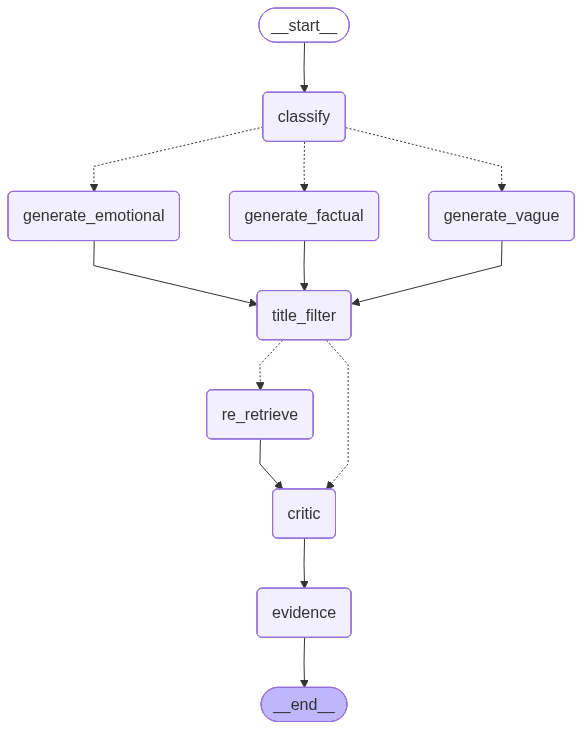

In [19]:
from langchain_core.runnables.graph import MermaidDrawMethod
display(
    Image(
        orchestrator_graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

## 9. Runner

In [20]:
def run_orchestrator(query: str) -> OrchestratorResult:
    final_state = orchestrator_graph.invoke({
        "question":    query,
        "retry_count": 0,
    })
    return OrchestratorResult(
        answer         = final_state.get("answer", ""),
        question_type  = QuestionType(final_state.get("question_type", "factual")),
        strategy       = final_state.get("strategy", ""),
        generator_used = final_state.get("generator_used", ""),
        evidence       = final_state.get("evidence", []),
        critic_judgment= final_state.get("critic_judgment", {}),
    )

## 10. Example Queries

In [24]:
# Factual → routed to LoRA agent
sample_query = "What make Benny Scanlon heatbreak in Overcompensating??"
result = run_orchestrator(sample_query)
print(f"Generator: {result.generator_used}")
print(f"Answer:    {result.answer}")
result

Generator: gpt
Answer:    In 'Overcompensating,' Benny begins to spend extra time with Carmen to avoid his feelings for Miles. His self-image takes a hit, leading him to spiral and potentially sabotage important aspects of his life.


OrchestratorResult(answer="In 'Overcompensating,' Benny begins to spend extra time with Carmen to avoid his feelings for Miles. His self-image takes a hit, leading him to spiral and potentially sabotage important aspects of his life.", question_type=<QuestionType.EMOTIONAL: 'emotional'>, strategy='rewrite_only', generator_used='gpt', evidence=[{'title': 'Overcompensating', 'id': 't_247619_5', 'snippet': 'After Benny comes out to Carmen, she decides to help him ease into gay life by setting him up on his first Grindr date. After his self-image takes a hit, Peter begins to spiral and decides to sabotage'}, {'title': 'Overcompensating', 'id': 't_247619_2', 'snippet': "To avoid his feelings for Miles, Benny begins to spend extra time with Carmen. Carmen begins to struggle as the anniversary of her brother's death arrives. Grace tries to find her own identity outside"}], critic_judgment={'supported': False, 'explanation': 'The answer incorrectly states that Benny experiences heartbreak whil

In [22]:
# Emotional → routed to GPT agent
emotional_query = "Why does Shane start a fake romance with Rose?"
result2 = run_orchestrator(emotional_query)
print(f"Generator: {result2.generator_used}")
print(f"Answer:    {result2.answer}")
result2

Generator: gpt
Answer:    Shane meets movie star Rose Landry and begins a public romance with her, which sparks jealousy in Ilya. This development occurs after an intimate moment between Shane and Ilya, leading to a series of events where they each express their feelings while navigating their complex relationship.


OrchestratorResult(answer='Shane meets movie star Rose Landry and begins a public romance with her, which sparks jealousy in Ilya. This development occurs after an intimate moment between Shane and Ilya, leading to a series of events where they each express their feelings while navigating their complex relationship.', question_type=<QuestionType.EMOTIONAL: 'emotional'>, strategy='rewrite_only', generator_used='gpt', evidence=[{'title': 'Heated Rivalry', 'id': 't_301507_3', 'snippet': 'Ilya and Shane continue to hook up from 2014 to 2016. In 2015, the Metros win their first cup in sixteen years and defend their title in 2016. When Shane and Ilya are asked by their friends about the '}, {'title': 'Happy Face', 'id': 't_243217_3', 'snippet': "Melissa, Ivy and their cameraman Tyler travel to Shane's house where they meet Gillian, Keith's new girlfriend. Gillian is excited to be interviewed for Dr. Greg's show, but Shane forbids filming in h"}, {'title': 'Heated Rivalry', 'id': 't_301507_5'

## 12. Evaluation

Comparing 4 systems:
- **A. Base LLM** — GPT-4o-mini with no retrieval
- **B. Basic RAG** — retriever + GPT-4o-mini
- **C. Advanced Agentic RAG (base model)** — full LangGraph pipeline, GPT-4o-mini only
- **D. Advanced Agentic RAG (LoRA fine-tuned)** — full LangGraph pipeline, LoRA for factual questions

In [27]:
test_questions = [
    "What make Benny Scanlon heatbreak in Overcompensating?",
    "How do Milo Bradford and his wife respond to the kidnapping?",
    "What is the name of the chef that gordon ramsay met for Māori cuisine?",
    "How do Lucy’s feelings about her breakup with Stephen and her guilt toward Evan affect her actions in this episode?",
    "Why Ilya ignored Shane's text?"
]
print(f"{len(test_questions)} test questions loaded")

5 test questions loaded


In [28]:
from collections import Counter

def token_f1(prediction: str, reference: str) -> float:
    """Token-level F1 between prediction and reference strings."""
    if not isinstance(prediction, str) or not isinstance(reference, str):
        return 0.0
    pred_tokens = prediction.lower().split()
    ref_tokens  = reference.lower().split()
    if not pred_tokens or not ref_tokens:
        return 0.0
    pred_counts = Counter(pred_tokens)
    ref_counts  = Counter(ref_tokens)
    common      = sum((pred_counts & ref_counts).values())
    if common == 0:
        return 0.0
    precision = common / len(pred_tokens)
    recall    = common / len(ref_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

## System A — Base LLM (no RAG)

In [33]:
def run_base_llm(question: str) -> str:
    response = (llm | StrOutputParser()).invoke(
        f"Answer the following question about a movie or TV plot in one or two sentences.\n\nQuestion: {question}"
    )
    return response.strip()



answers_base_llm = []
for q in test_questions:
    ans = run_base_llm(q)
    answers_base_llm.append(ans)
    print(f"\nQ: {q}")
    print(f"A: {ans}")



Q: What make Benny Scanlon heatbreak in Overcompensating?
A: In "Overcompensating," Benny Scanlon experiences heartbreak when he realizes that his romantic feelings for his best friend are unreciprocated, leading him to confront his feelings about love and friendship. This emotional struggle forces Benny to reassess his relationships and personal identity.

Q: How do Milo Bradford and his wife respond to the kidnapping?
A: In response to the kidnapping, Milo Bradford and his wife take drastic measures, including enlisting the help of law enforcement and conducting their own investigation, while grappling with intense emotions and the fear for their child's safety. Their determination leads them to uncover shocking truths about the circumstances surrounding the abduction.

Q: What is the name of the chef that gordon ramsay met for Māori cuisine?
A: Gordon Ramsay met chef and Māori cuisine expert, Peter Gordon, during his exploration of New Zealand's culinary traditions.

Q: How do Lucy

## System B — Base RAG

In [29]:
def run_basic_rag(question: str) -> str:
    """Retrieve top-10 chunks → GPT-4o-mini. No reranking, no agents."""
    docs    = retriever.invoke(question)
    context = format_docs(docs)
    answer  = (prompt | llm | StrOutputParser()).invoke(
        {"context": context, "question": question}
    )
    return answer.strip()


print("Running System B — Basic RAG...")
answers_b = []
for q in test_questions:
    ans = run_basic_rag(q)
    answers_b.append(ans)
    print(f"Q: {q[:60]}...")
    print(f"A: {ans[:100]}\n")

Running System B — Basic RAG...
Q: What make Benny Scanlon heatbreak in Overcompensating?...
A: Benny Scanlon experiences heartbreak in "Overcompensating" due to his feelings of inadequacy and sel

Q: How do Milo Bradford and his wife respond to the kidnapping?...
A: Milo Bradford and his wife, Marissa, respond to their son's kidnapping by trying to manage the publi

Q: What is the name of the chef that gordon ramsay met for Māor...
A: The chef that Gordon Ramsay met for Māori cuisine is Monique Fiso.

Q: How do Lucy’s feelings about her breakup with Stephen and he...
A: Lucy grapples with her emotions regarding her breakup with Stephen and her guilt toward Evan, which 

Q: Why Ilya ignored Shane's text?...
A: Ilya ignored Shane's texts after his team performed poorly at the 2014 Winter Olympics in Sochi. Thi



## System C — Advanced agentic RAG with base model 

In [40]:
df = pd.read_csv("evaluation_report/based_agent_results.csv")
for i in range(len(df)):
    print("Q: ", df.iloc[i]["query"])
    print("A: ", df.iloc[i]["answer"])
    print("\n")

Q:  What is the occupation of Ilya and Shane in Heated Rivery?
A:  Ilya Rozanov is a hockey player drafted by the Boston Raiders, and Shane Hollander is a hockey player drafted by the Montreal Metros. Both of them are involved in the Major League Hockey (MLH). Their relationship is a central theme in the narrative of "Heated Rivery."


Q:  What make Benny Scanlon heatbreak in Overcompensating??
A:  Benny Scanlon navigates complex feelings in 'Overcompensating' after coming out to Carmen. To avoid his feelings for Miles, he begins spending more time with Carmen, who is also dealing with her own struggles. Carmen helps Benny ease into gay life by setting him up on a Grindr date, reflecting the complexity of their friendship amid their individual challenges.


Q:  How do Milo Bradford and his wife respond to the kidnapping?
A:  Conrad Cain and his wife Ellie are deeply affected by their son Leopold's kidnapping, which is compounded by media attention and the complexities of the case. As a

## System D — Advanced Agentic RAG (LoRA Fine-tuned)

In [30]:
# Uses run_orchestrator() from your original a4_multiagent notebook
# All agents use GPT-4o-mini — no LoRA

print("Running System C — Advanced Agentic RAG (base model)...")
answers_c = []
for q in test_questions:
    result = run_orchestrator(q)   # base model orchestrator
    answers_c.append(result.answer)
    print(f"Q: {q[:60]}...")
    print(f"Type: {result.question_type} | Strategy: {result.strategy}")
    print(f"A: {result.answer[:100]}\n")

Running System C — Advanced Agentic RAG (base model)...
Q: What make Benny Scanlon heatbreak in Overcompensating?...
Type: factual | Strategy: lora_rewrite_rerank
A: Benny's heartbreak in Overcompensating is related to his internal struggle with his feelings for Mil

Q: How do Milo Bradford and his wife respond to the kidnapping?...
Type: emotional | Strategy: rewrite_only
A: When Milo Bradford, the son of Los Angeles mayoral candidate Milo Bradford, is kidnapped, he and his

Q: What is the name of the chef that gordon ramsay met for Māor...
Type: factual | Strategy: lora_rewrite_rerank
A: Gordon Ramsay embarks on culinary adventures across various countries, including New Zealand, Indone

Q: How do Lucy’s feelings about her breakup with Stephen and he...
Type: emotional | Strategy: rewrite_only
A: In this episode, Lucy deals with complex emotions related to her relationship with Stephen, which ha

Q: Why Ilya ignored Shane's text?...
Type: emotional | Strategy: rewrite_only
A: Ilya be

# Discussion 

From the results, we can observe clear improvement at each stage of the pipeline.

With the base LLM, answers are generally fabricated since the specific plot details are not present in the model's training data. The model produces plausible-sounding but inaccurate responses.

With basic RAG, answers become more grounded as the retriever supplies relevant plot chunks as context. However, the answers tend to be verbose and redundant, often restating surrounding context rather than directly addressing the question.

With the advanced agentic RAG using the base model, answers become more concise and accurate. The critic agent filters out unsupported claims, and the title filter agent leverages chunk metadata to remove noise from the retrieved documents, ensuring the generator only sees chunks from the correct show or movie.

With the LoRA fine-tuned model handling factual questions, the answers improve further in precision. Because the model was fine-tuned on NarrativeQA — a movie plot QA dataset focused on short, direct answers — it learns to extract the key information rather than elaborating with surrounding context. As a result, the answer to the question appears at the beginning of the response, making it immediately readable without having to parse through a long passage to find the relevant detail.